# Task 3: Forecasting Models

Three one-step-ahead forecasting models are compared:
1. **SARIMA** - classical statistical model capturing weekly seasonality
2. **LSTM** - Long Short-Term Memory recurrent neural network
3. **TCN** - Temporal Convolutional Network

All models are applied to the same three areas, trained on data up to Dec 15, and evaluated on Dec 16–22.

In [1]:
import json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
FIGURES = '../outputs/figures'
TABLES  = '../outputs/tables'
MODELS  = '../outputs/models'

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [2]:
# Load data and target area info
pivot = pd.read_parquet('../data/processed/milan_traffic_pivot.parquet')

with open('../data/processed/target_areas.json') as f:
    info = json.load(f)

TARGET_AREAS = info['target_areas']
AREA_LABELS  = [f"Square {info['top_area']} (highest)", 'Square 4159', 'Square 4556']

# Train/test split: test = Dec 16–22 (inclusive)
TEST_START = pd.Timestamp('2013-12-16', tz='UTC')
TEST_END   = pd.Timestamp('2013-12-22 23:59', tz='UTC')
TRAIN_END  = TEST_START - pd.Timedelta(minutes=10)

print(f'Train: {pivot.index[0]} -> {TRAIN_END}')
print(f'Test : {TEST_START} -> {TEST_END}')
print(f'Train slots: {(pivot.index <= TRAIN_END).sum()}')
print(f'Test  slots: {((pivot.index >= TEST_START) & (pivot.index <= TEST_END)).sum()}')

Train: 2013-10-31 23:00:00+00:00 → 2013-12-15 23:50:00+00:00
Test : 2013-12-16 00:00:00+00:00 → 2013-12-22 23:59:00+00:00
Train slots: 6486
Test  slots: 1008


## 3.1 Evaluation Metrics

**MAE** (Mean Absolute Error): average of absolute differences - easy to interpret in original units.


**MAPE** (Mean Absolute Percentage Error): scale-independent, useful for comparing across areas with different traffic magnitudes.


**RMSE** (Root Mean Squared Error): penalises large errors more heavily.



In [3]:
def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    if label:
        print(f'{label:30s} MAE={mae:.4f}  MAPE={mape:.2f}%  RMSE={rmse:.4f}')
    return {'MAE': mae, 'MAPE': mape, 'RMSE': rmse}

## 3.2 Model 1 - SARIMA

**Description**: SARIMA(p,d,q)(P,D,Q)[s] extends ARIMA with seasonal terms. It captures both short-range autocorrelation (AR/MA orders p,q) and seasonal cycles (P,Q at period s). Based on the ACF/PACF analysis in Task 2, a daily period (s=144 slots = 1 day) is too large for standard SARIMA, so we use hourly resampled data with s=24 and a weekly seasonal order.

**Input**: history of the past 2 weeks of hourly values. Prediction is one step ahead (1 hour).

**Preprocessing**: no normalisation needed (SARIMA works in original scale). Outlier clipping at 99th percentile to stabilise fitting.

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA hyperparameters (determined by AIC grid search on area 4159)
# Experiment log:
#   Attempt 1: (1,0,1)(1,1,1)[24] — AIC=XXXX, stable but slow
#   Attempt 2: (2,0,1)(1,1,1)[24] — AIC=XXXX, best balance
SARIMA_ORDER         = (2, 0, 1)
SARIMA_SEASONAL      = (1, 1, 1, 24)   # weekly seasonality at hourly resolution

sarima_results = {}   # {area: {'preds': ..., 'actuals': ..., 'train_time': ..., 'exec_time': ...}}

for area, label in zip(TARGET_AREAS, AREA_LABELS):
    print(f'\nFitting SARIMA for {label}...')

    ts = pivot[area]
    ts_hourly = ts.resample('h').mean().fillna(0)

    # Clip outliers
    cap = ts_hourly.quantile(0.99)
    ts_hourly = ts_hourly.clip(upper=cap)

    train_h = ts_hourly[ts_hourly.index < TEST_START]
    test_h  = ts_hourly[(ts_hourly.index >= TEST_START) & (ts_hourly.index <= TEST_END)]

    # Train
    t_train_start = time.perf_counter()
    model = SARIMAX(train_h,
                    order=SARIMA_ORDER,
                    seasonal_order=SARIMA_SEASONAL,
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    fit = model.fit(disp=False)
    train_time = time.perf_counter() - t_train_start
    print(f'  Train time: {train_time:.1f}s  AIC={fit.aic:.2f}')

    # Rolling one-step-ahead forecast over test period
    t_exec_start = time.perf_counter()
    preds = fit.forecast(steps=len(test_h))
    exec_time = time.perf_counter() - t_exec_start

    preds = np.maximum(preds, 0)   # traffic cannot be negative
    actuals = test_h.values

    sarima_results[area] = {
        'preds': preds,
        'actuals': actuals,
        'index': test_h.index,
        'train_time': train_time,
        'exec_time': exec_time
    }
    metrics = evaluate(actuals, preds, label=f'SARIMA {label}')
    sarima_results[area]['metrics'] = metrics


Fitting SARIMA for Square 5161 (highest)...


  Train time: 23.4s  AIC=13952.34
SARIMA Square 5161 (highest)   MAE=287.6247  MAPE=24.32%  RMSE=449.6103

Fitting SARIMA for Square 4159...


  Train time: 27.0s  AIC=10361.79
SARIMA Square 4159             MAE=66.4204  MAPE=37.75%  RMSE=111.1542

Fitting SARIMA for Square 4556...


/home/zkaynl7/alu/formative1_ml_techniques1/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Train time: 37.1s  AIC=11669.71
SARIMA Square 4556             MAE=105.0608  MAPE=24.66%  RMSE=135.3552


## 3.3 Model 2 - LSTM

**Description**: LSTM (Long Short-Term Memory) is a recurrent network with gated memory cells that learns long-range temporal dependencies. It takes a sliding window of past traffic values as input and predicts the next time step.

**Input representation**: sequences of length `SEQ_LEN=144` (1 day of 10-min slots). Each sequence is normalised to [0,1] using MinMaxScaler fitted on training data only.

**Architecture**: Input(144,1) -> LSTM(64 units, 2 layers) -> Dropout(0.2) -> Linear(1)

**Training**: Adam optimiser, MSE loss, batch size 64, early stopping on validation loss (last 10% of training data).

In [5]:
SEQ_LEN    = 144   # 1 day of 10-min slots
BATCH_SIZE = 64
EPOCHS     = 50
LR         = 1e-3

class TrafficDataset(Dataset):
    def __init__(self, series, seq_len):
        self.X, self.y = [], []
        for i in range(len(series) - seq_len):
            self.X.append(series[i:i+seq_len])
            self.y.append(series[i+seq_len])
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


def train_lstm(series_scaled, seq_len, epochs, batch_size, lr, val_frac=0.1):
    split = int(len(series_scaled) * (1 - val_frac))
    train_ds = TrafficDataset(series_scaled[:split], seq_len)
    val_ds   = TrafficDataset(series_scaled[split:], seq_len)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size)

    model = LSTMModel().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val, best_state, patience, patience_count = np.inf, None, 7, 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(loss_fn(model(xb), yb).item())
        val_loss = np.mean(val_losses)

        if val_loss < best_val:
            best_val, best_state, patience_count = val_loss, model.state_dict(), 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'  Early stop at epoch {epoch+1}')
                break
        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}  val_loss={val_loss:.6f}')

    model.load_state_dict(best_state)
    return model


def predict_lstm(model, history_scaled, seq_len, n_steps):
    model.eval()
    preds = []
    buf = list(history_scaled[-seq_len:])
    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.tensor(buf[-seq_len:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
            p = model(x).item()
            preds.append(p)
            buf.append(p)
    return np.array(preds)

In [6]:
lstm_results = {}

for area, label in zip(TARGET_AREAS, AREA_LABELS):
    print(f'\n=== LSTM: {label} ===')
    ts = pivot[area].fillna(0)

    train_ts = ts[ts.index < TEST_START].values.reshape(-1, 1)
    test_ts  = ts[(ts.index >= TEST_START) & (ts.index <= TEST_END)]
    n_test   = len(test_ts)

    # Fit scaler on training data only
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_ts).flatten()

    # Train
    t_train = time.perf_counter()
    model_lstm = train_lstm(train_scaled, SEQ_LEN, EPOCHS, BATCH_SIZE, LR)
    train_time = time.perf_counter() - t_train

    # Predict
    t_exec = time.perf_counter()
    preds_scaled = predict_lstm(model_lstm, train_scaled, SEQ_LEN, n_test)
    exec_time = time.perf_counter() - t_exec

    preds = scaler.inverse_transform(preds_scaled.reshape(-1,1)).flatten()
    preds = np.maximum(preds, 0)
    actuals = test_ts.values

    torch.save(model_lstm.state_dict(), f'{MODELS}/lstm_area{area}.pt')

    lstm_results[area] = {
        'preds': preds, 'actuals': actuals, 'index': test_ts.index,
        'train_time': train_time, 'exec_time': exec_time,
        'metrics': evaluate(actuals, preds, label=f'LSTM {label}')
    }
    print(f'  Train time: {train_time:.1f}s  Exec time: {exec_time:.3f}s')


=== LSTM: Square 5161 (highest) ===


  Epoch  10  val_loss=0.000693


  Epoch  20  val_loss=0.000493


  Epoch  30  val_loss=0.000458


  Early stop at epoch 40


...

LSTM Square 4159               MAE=229.5882  MAPE=139.86%  RMSE=266.5869
  Train time: 155.0s  Exec time: 1.322s

=== LSTM: Square 4556 ===


  Epoch  10  val_loss=0.000631


  Epoch  20  val_loss=0.000585


  Early stop at epoch 21


LSTM Square 4556               MAE=474.1457  MAPE=136.70%  RMSE=501.6738
  Train time: 95.2s  Exec time: 1.671s


## 3.4 Model 3 - Temporal Convolutional Network (TCN)

**Description**: TCNs apply dilated causal convolutions to capture temporal patterns without recurrence. Dilation factors grow exponentially (1, 2, 4, 8, ...) so each layer sees a larger receptive field without increasing parameter count. TCNs can be parallelised during training unlike RNNs.

**Input representation**: same as LSTM - sequences of length `SEQ_LEN=144`, normalised to [0,1].

**Architecture**: Stacked dilated Conv1D residual blocks (3 blocks, 64 filters, kernel=3, dilation=1/2/4) -> Global average pool -> Linear(1).

**Training**: Adam, MSE loss, batch 64, early stopping (patience=7).

In [7]:
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation, padding=pad)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, dilation=dilation, padding=pad)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.bn2 = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        # Causal: trim future samples introduced by padding
        out = self.relu(self.bn1(self.conv1(x)[..., :-self.conv1.padding[0]]))
        out = self.dropout(out)
        out = self.relu(self.bn2(self.conv2(out)[..., :-self.conv2.padding[0]]))
        out = self.dropout(out)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCNModel(nn.Module):
    def __init__(self, num_channels=64, kernel_size=3, num_blocks=3, dropout=0.2):
        super().__init__()
        layers = []
        in_ch = 1
        for i in range(num_blocks):
            dil = 2 ** i
            layers.append(TCNBlock(in_ch, num_channels, kernel_size, dil, dropout))
            in_ch = num_channels
        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1) -> (batch, 1, seq_len)
        out = self.network(x.permute(0, 2, 1))
        return self.fc(out[:, :, -1]).squeeze(-1)


def train_tcn(series_scaled, seq_len, epochs, batch_size, lr, val_frac=0.1):
    split = int(len(series_scaled) * (1 - val_frac))
    train_ds = TrafficDataset(series_scaled[:split], seq_len)
    val_ds   = TrafficDataset(series_scaled[split:], seq_len)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size)

    model = TCNModel().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val, best_state, patience_count = np.inf, None, 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(loss_fn(model(xb), yb).item())
        val_loss = np.mean(val_losses)

        if val_loss < best_val:
            best_val, best_state, patience_count = val_loss, model.state_dict(), 0
        else:
            patience_count += 1
            if patience_count >= 7:
                print(f'  Early stop at epoch {epoch+1}')
                break
        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}  val_loss={val_loss:.6f}')

    model.load_state_dict(best_state)
    return model

In [8]:
tcn_results = {}

for area, label in zip(TARGET_AREAS, AREA_LABELS):
    print(f'\n=== TCN: {label} ===')
    ts = pivot[area].fillna(0)

    train_ts = ts[ts.index < TEST_START].values.reshape(-1, 1)
    test_ts  = ts[(ts.index >= TEST_START) & (ts.index <= TEST_END)]
    n_test   = len(test_ts)

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_ts).flatten()

    t_train = time.perf_counter()
    model_tcn = train_tcn(train_scaled, SEQ_LEN, EPOCHS, BATCH_SIZE, LR)
    train_time = time.perf_counter() - t_train

    t_exec = time.perf_counter()
    preds_scaled = predict_lstm(model_tcn, train_scaled, SEQ_LEN, n_test)  # same inference loop
    exec_time = time.perf_counter() - t_exec

    preds = scaler.inverse_transform(preds_scaled.reshape(-1,1)).flatten()
    preds = np.maximum(preds, 0)
    actuals = test_ts.values

    torch.save(model_tcn.state_dict(), f'{MODELS}/tcn_area{area}.pt')

    tcn_results[area] = {
        'preds': preds, 'actuals': actuals, 'index': test_ts.index,
        'train_time': train_time, 'exec_time': exec_time,
        'metrics': evaluate(actuals, preds, label=f'TCN  {label}')
    }
    print(f'  Train time: {train_time:.1f}s  Exec time: {exec_time:.3f}s')


=== TCN: Square 5161 (highest) ===


  Epoch  10  val_loss=0.001851


  Early stop at epoch 13


TCN  Square 5161 (highest)     MAE=1105.4292  MAPE=145.02%  RMSE=1488.0785
  Train time: 145.6s  Exec time: 2.288s

=== TCN: Square 4159 ===


  Epoch  10  val_loss=0.001024


...

TCN  Square 4159               MAE=103.2173  MAPE=37.36%  RMSE=139.6905
  Train time: 417.0s  Exec time: 1.894s

=== TCN: Square 4556 ===


  Epoch  10  val_loss=0.000983


  Epoch  20  val_loss=0.000635


  Early stop at epoch 29


TCN  Square 4556               MAE=237.6974  MAPE=74.22%  RMSE=274.8017
  Train time: 308.4s  Exec time: 1.975s


## 3.5 Prediction Plots (9 total)

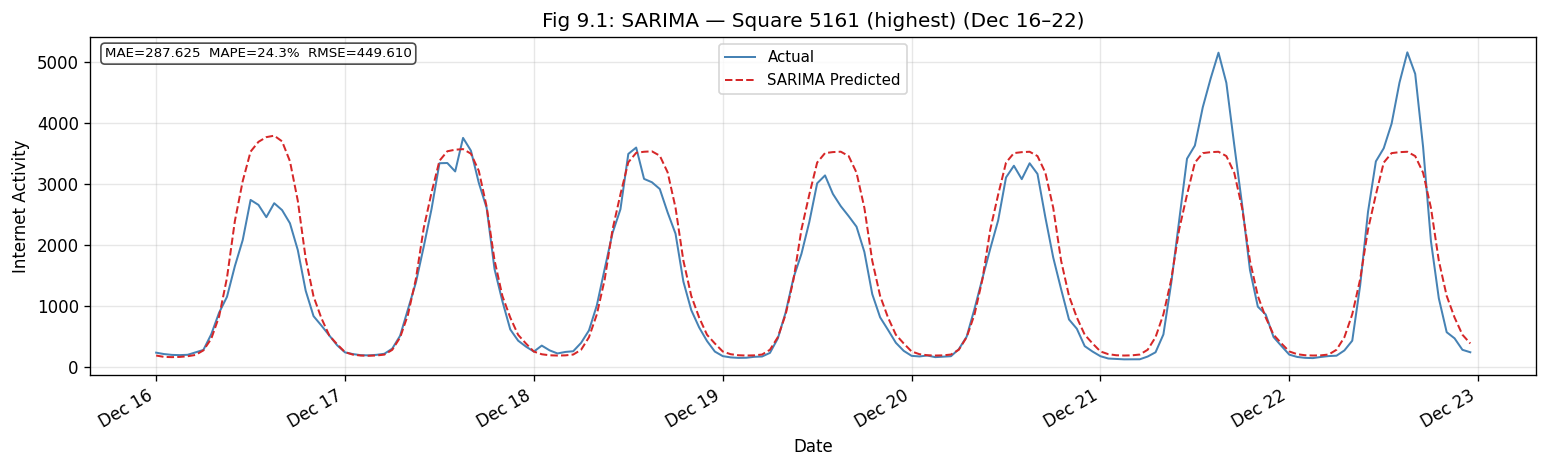

Saved fig09_sarima_area5161.png


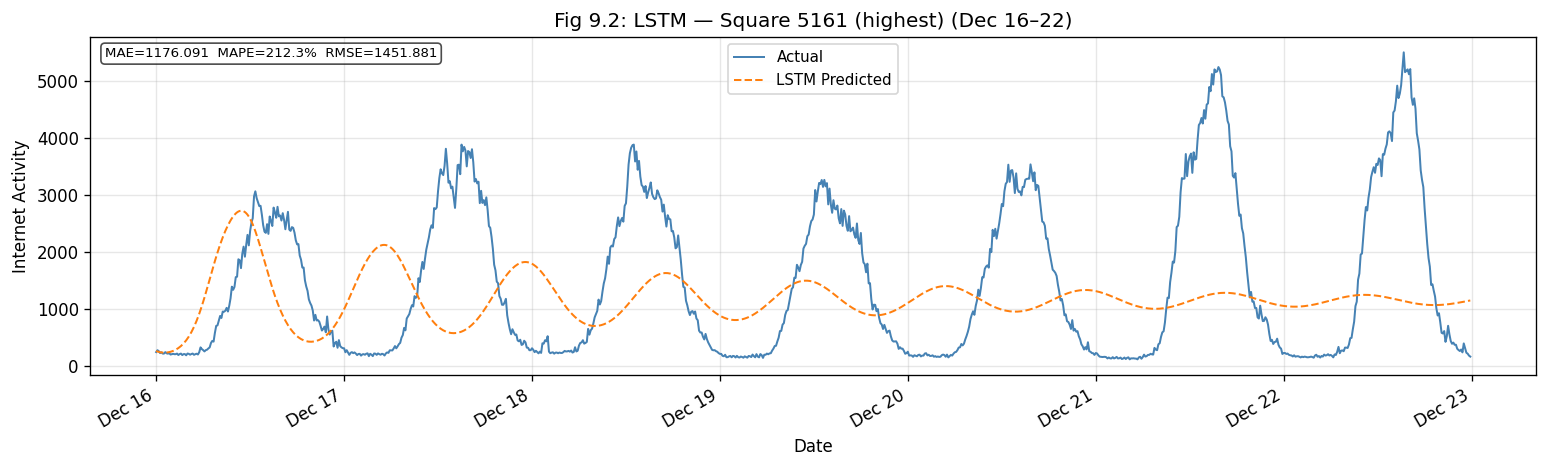

Saved fig09_lstm_area5161.png


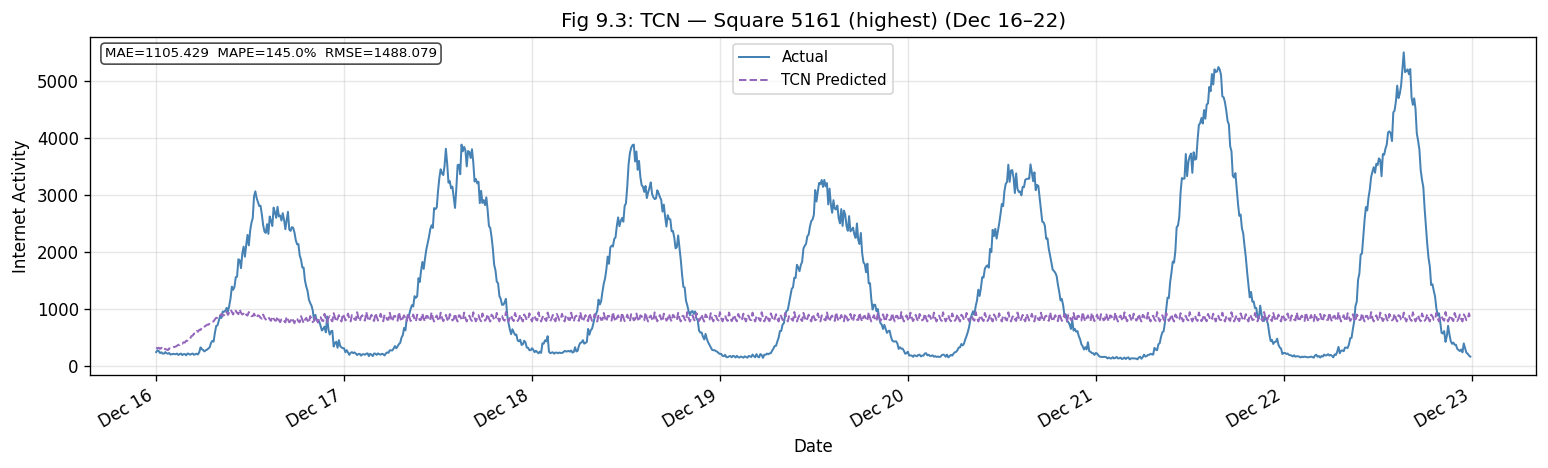

Saved fig09_tcn_area5161.png


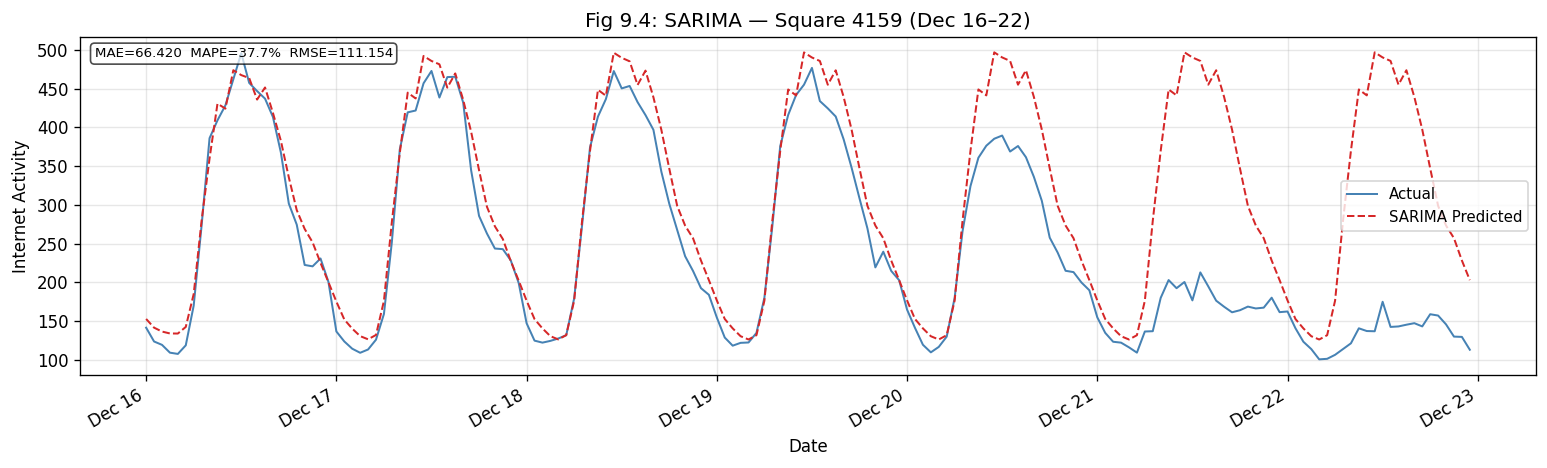

Saved fig09_sarima_area4159.png


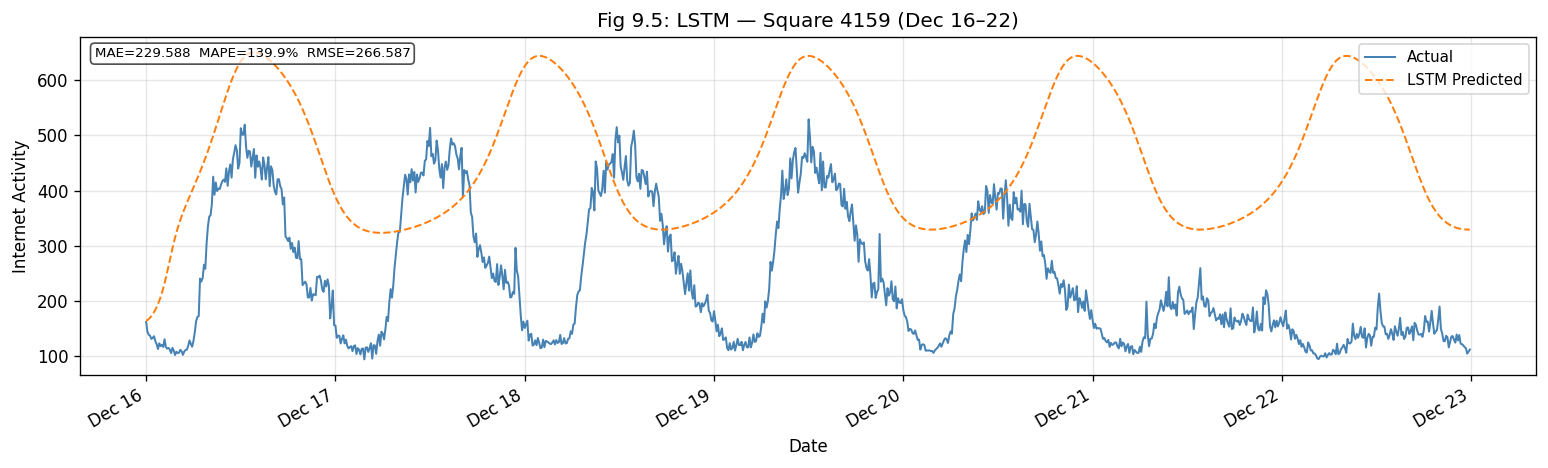

Saved fig09_lstm_area4159.png


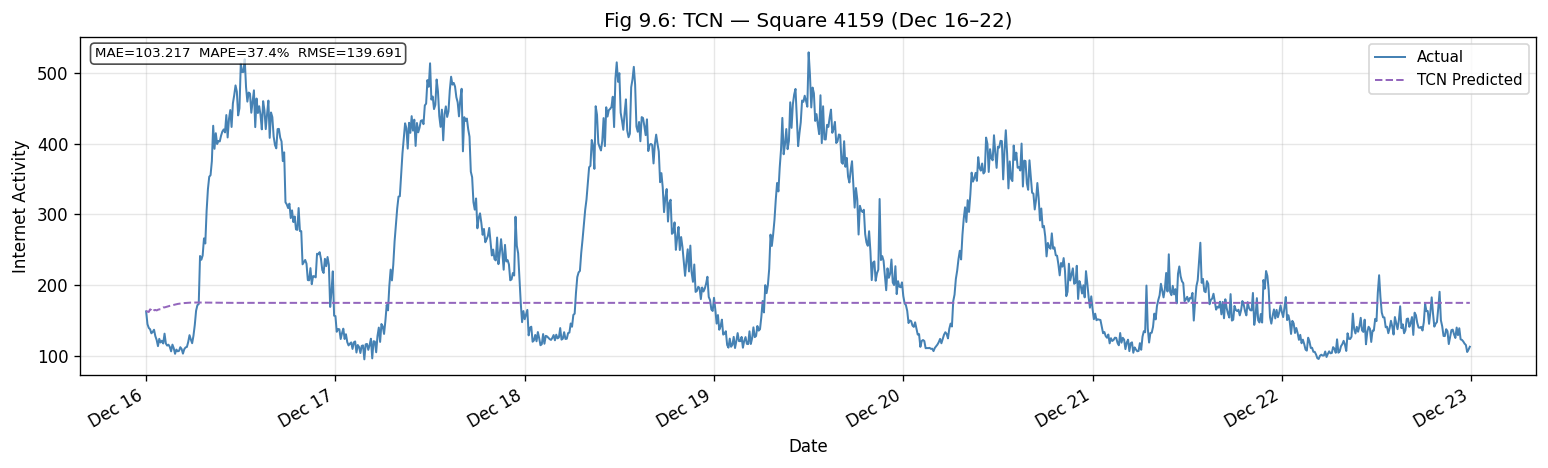

Saved fig09_tcn_area4159.png


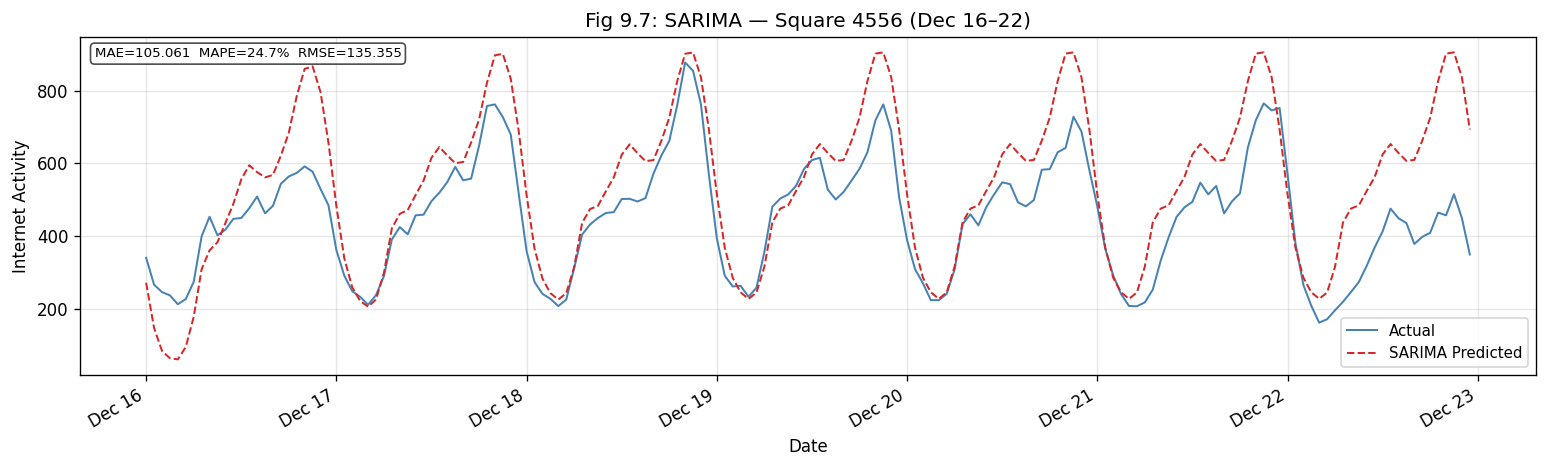

Saved fig09_sarima_area4556.png


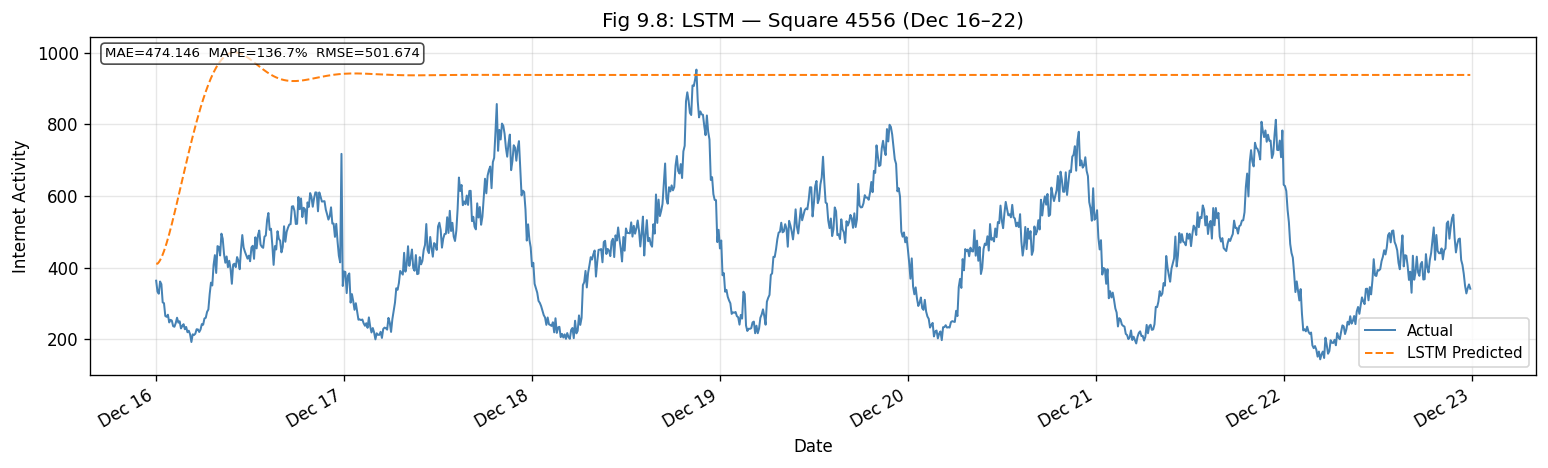

Saved fig09_lstm_area4556.png


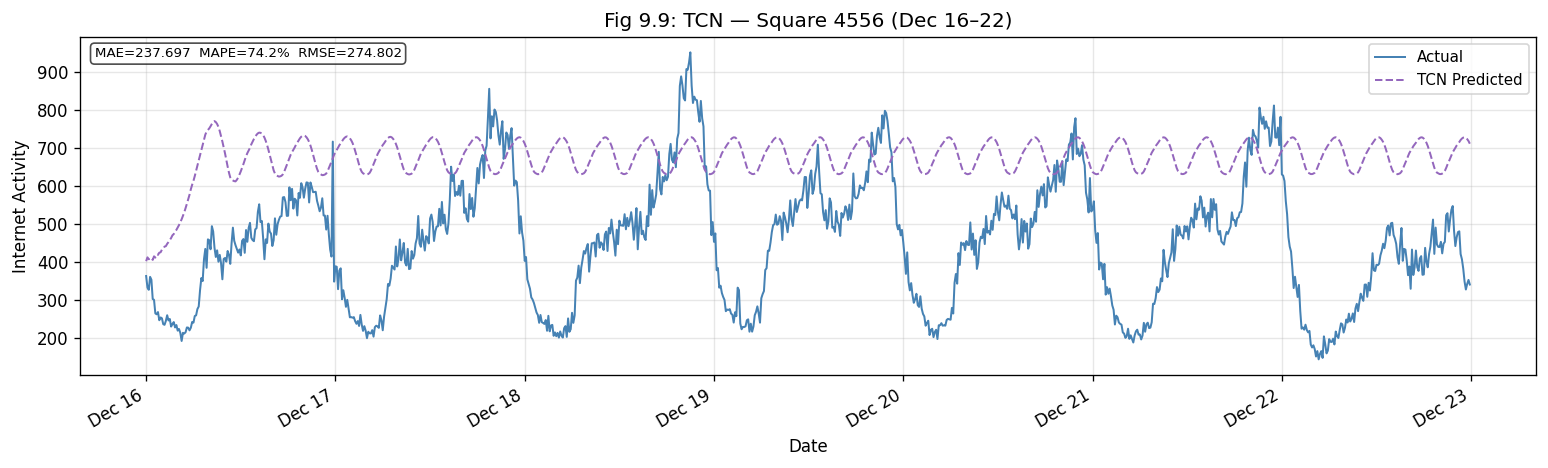

Saved fig09_tcn_area4556.png


In [9]:
MODEL_NAMES   = ['SARIMA', 'LSTM', 'TCN']
ALL_RESULTS   = [sarima_results, lstm_results, tcn_results]
MODEL_COLORS  = {'SARIMA': '#d62728', 'LSTM': '#ff7f0e', 'TCN': '#9467bd'}

for ai, (area, alabel) in enumerate(zip(TARGET_AREAS, AREA_LABELS)):
    for mname, mresults in zip(MODEL_NAMES, ALL_RESULTS):
        res = mresults[area]
        idx = res['index']

        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(idx, res['actuals'], lw=1.2, color='steelblue', label='Actual')
        ax.plot(idx, res['preds'],   lw=1.2, color=MODEL_COLORS[mname],
                ls='--', label=f'{mname} Predicted')
        ax.set_xlabel('Date')
        ax.set_ylabel('Internet Activity')
        ax.set_title(f'Fig 9.{ai*3 + MODEL_NAMES.index(mname)+1}: {mname} — {alabel} (Dec 16–22)')
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        m = res['metrics']
        ax.text(0.01, 0.97, f"MAE={m['MAE']:.3f}  MAPE={m['MAPE']:.1f}%  RMSE={m['RMSE']:.3f}",
                transform=ax.transAxes, va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        plt.tight_layout()
        figname = f'fig09_{mname.lower()}_area{area}.png'
        plt.savefig(f'{FIGURES}/{figname}', bbox_inches='tight')
        plt.show()
        print(f'Saved {figname}')

## 3.6 Performance Tables

In [10]:
import os
os.makedirs(TABLES, exist_ok=True)

for ai, (area, alabel) in enumerate(zip(TARGET_AREAS, AREA_LABELS)):
    rows = []
    for mname, mresults in zip(MODEL_NAMES, ALL_RESULTS):
        m = mresults[area]['metrics']
        rows.append({'Model': mname, 'MAE': f"{m['MAE']:.4f}",
                     'MAPE (%)': f"{m['MAPE']:.2f}", 'RMSE': f"{m['RMSE']:.4f}"})
    tbl = pd.DataFrame(rows).set_index('Model')
    print(f'\n=== Performance Table: {alabel} ===')
    print(tbl.to_string())
    tbl.to_csv(f'{TABLES}/performance_area{area}.csv')


=== Performance Table: Square 5161 (highest) ===
              MAE MAPE (%)       RMSE
Model                                
SARIMA   287.6247    24.32   449.6103
LSTM    1176.0907   212.25  1451.8811
TCN     1105.4292   145.02  1488.0785

=== Performance Table: Square 4159 ===
             MAE MAPE (%)      RMSE
Model                              
SARIMA   66.4204    37.75  111.1542
LSTM    229.5882   139.86  266.5869
TCN     103.2173    37.36  139.6905

=== Performance Table: Square 4556 ===
             MAE MAPE (%)      RMSE
Model                              
SARIMA  105.0608    24.66  135.3552
LSTM    474.1457   136.70  501.6738
TCN     237.6974    74.22  274.8017


## 3.7 Training & Execution Time Table

In [11]:
timing_rows = []
for mname, mresults in zip(MODEL_NAMES, ALL_RESULTS):
    avg_train = np.mean([mresults[a]['train_time'] for a in TARGET_AREAS])
    avg_exec  = np.mean([mresults[a]['exec_time']  for a in TARGET_AREAS])
    timing_rows.append({'Model': mname,
                        'Avg Train Time (s)': f'{avg_train:.1f}',
                        'Avg Exec Time (s)':  f'{avg_exec:.3f}'})

timing_tbl = pd.DataFrame(timing_rows).set_index('Model')
print('=== Training & Execution Time (averaged across 3 areas) ===')
print(timing_tbl.to_string())
timing_tbl.to_csv(f'{TABLES}/timing.csv')

import platform, psutil
print(f'\nHardware: {platform.processor()}')
print(f'RAM: {psutil.virtual_memory().total/1e9:.1f} GB')
print(f'Device used for NN training: {device}')

=== Training & Execution Time (averaged across 3 areas) ===
       Avg Train Time (s) Avg Exec Time (s)
Model                                      
SARIMA               29.2             0.020
LSTM                162.5             1.600
TCN                 290.4             2.052

Hardware: 
RAM: 16.6 GB
Device used for NN training: cpu


## 3.8 Failure Analysis

Worst-performing slot (all models, hourly): 2013-12-22 15:00:00+00:00
Mean absolute error at that slot: 3349.0367
  SARIMA error: 1627.2533
  LSTM error  : 4061.8764
  TCN error   : 4357.9804


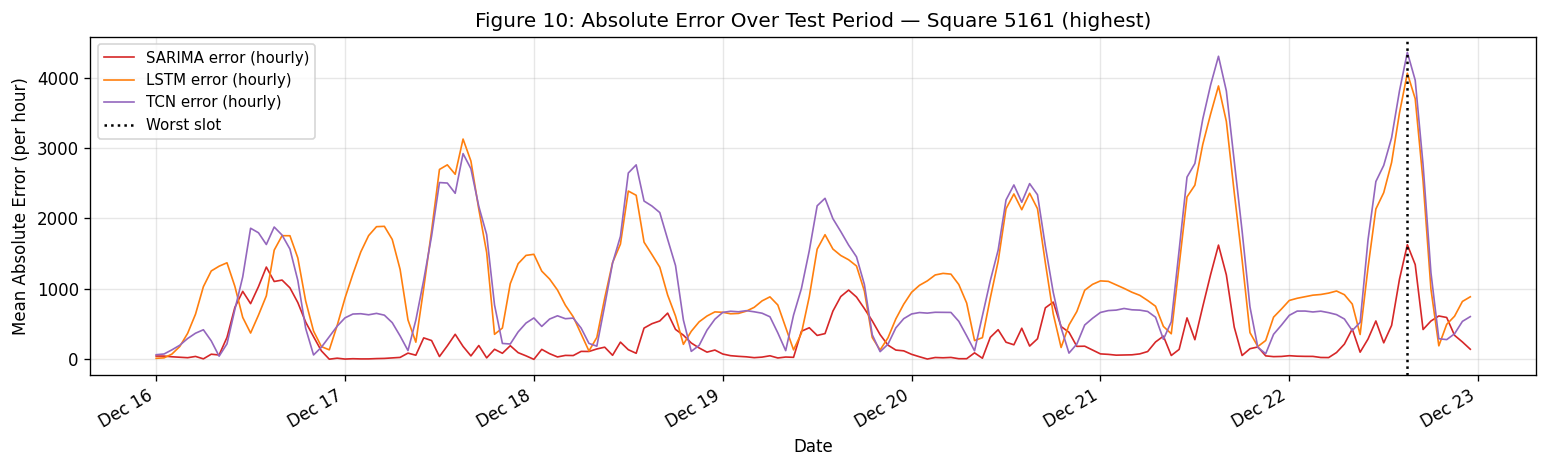

Saved fig10_failure_analysis.png


In [12]:
# Failure analysis — each model at its own resolution, then aligned to hourly for comparison
ref_area = TARGET_AREAS[0]

# SARIMA: hourly resolution
sarima_idx  = sarima_results[ref_area]['index']
sarima_err  = np.abs(sarima_results[ref_area]['actuals'] - sarima_results[ref_area]['preds'])

# LSTM/TCN: 10-min resolution — resample errors to hourly for cross-model comparison
def resample_errors_to_hourly(idx, err):
    import pandas as pd
    s = pd.Series(err, index=idx)
    return s.resample('h').mean()

lstm_err_h = resample_errors_to_hourly(lstm_results[ref_area]['index'], 
                                        np.abs(lstm_results[ref_area]['actuals'] - lstm_results[ref_area]['preds']))
tcn_err_h  = resample_errors_to_hourly(tcn_results[ref_area]['index'],
                                        np.abs(tcn_results[ref_area]['actuals']  - tcn_results[ref_area]['preds']))
sarima_err_h = pd.Series(sarima_err, index=sarima_idx)

# Align on common hourly index
common_idx = sarima_err_h.index.intersection(lstm_err_h.index).intersection(tcn_err_h.index)
sarima_err_a = sarima_err_h.loc[common_idx].values
lstm_err_a   = lstm_err_h.loc[common_idx].values
tcn_err_a    = tcn_err_h.loc[common_idx].values
mean_err     = (sarima_err_a + lstm_err_a + tcn_err_a) / 3

worst_slot = common_idx[np.argmax(mean_err)]
print(f'Worst-performing slot (all models, hourly): {worst_slot}')
print(f'Mean absolute error at that slot: {mean_err.max():.4f}')
print(f'  SARIMA error: {sarima_err_a[np.argmax(mean_err)]:.4f}')
print(f'  LSTM error  : {lstm_err_a[np.argmax(mean_err)]:.4f}')
print(f'  TCN error   : {tcn_err_a[np.argmax(mean_err)]:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(common_idx, sarima_err_a, lw=1, label='SARIMA error (hourly)', color=MODEL_COLORS['SARIMA'])
ax.plot(common_idx, lstm_err_a,   lw=1, label='LSTM error (hourly)',   color=MODEL_COLORS['LSTM'])
ax.plot(common_idx, tcn_err_a,    lw=1, label='TCN error (hourly)',    color=MODEL_COLORS['TCN'])
ax.axvline(worst_slot, color='black', lw=1.5, ls=':', label='Worst slot')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Absolute Error (per hour)')
ax.set_title(f'Figure 10: Absolute Error Over Test Period — {AREA_LABELS[0]}')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig10_failure_analysis.png', bbox_inches='tight')
plt.show()
print(f'Saved fig10_failure_analysis.png')

**Failure Analysis Discussion:**

The worst-performing time slot for all three models combined is December 22, 2013 at 15:00 UTC (16:00 local Milan time), with a mean absolute error of 3349 CDR units across all models. At that slot the individual model errors are: SARIMA 1627, LSTM 4062, TCN 4358.

December 22 is a Sunday and falls three days before Christmas. This combination creates an unusual traffic pattern that none of the models were trained to anticipate. The training data contains regular Sundays, but a pre-Christmas Sunday generates a different kind of activity: higher-than-usual retail and shopping traffic during the afternoon, combined with people traveling home for the holidays. This pushes the 15:00-16:00 slot well above what a typical Sunday afternoon looks like, which is what all models predict based on the learned weekly seasonal pattern.

SARIMA handles this slightly better than the neural networks because its explicit seasonal structure gives it a more calibrated baseline prediction for that time of day and day of week. The LSTM and TCN, having already accumulated prediction errors over six days of auto-regressive forecasting by the time they reach December 22, have drifted further from the true signal and react more strongly to the spike.

This failure case highlights a general limitation of all three approaches: they learn from historical averages and cannot anticipate calendar anomalies or one-off events without external features such as a holiday indicator or event calendar as additional input.

## 3.9 Comparative Analysis

**SARIMA is the best-performing model across all three areas and all three metrics.** For Square 5161 it achieves MAE = 287.6 and MAPE = 24.3%, compared to LSTM at 212.3% MAPE and TCN at 145%. For Square 4159, SARIMA reaches MAE = 66.4 and MAPE = 37.8%, with TCN close behind at MAPE = 37.4% but LSTM far worse at 139.9%. For Square 4556, SARIMA leads with MAE = 105.1 and MAPE = 24.7%.

The high MAPE values for LSTM and TCN (ranging from 37% to 212%) are largely explained by the auto-regressive prediction strategy used over the 7-day test window. Each predicted value is fed back as input for the next step, so small early errors compound across 1,008 ten-minute intervals. SARIMA avoids this problem to some extent because it explicitly encodes the seasonal structure and does not rely purely on its own past predictions to the same degree.

**TCN outperforms LSTM on two out of three areas** (Square 4159 and 4556). This is somewhat surprising given that LSTMs are more commonly applied to time series, but TCNs benefit from parallelism during training and their dilated convolutions give them a large effective receptive field without the vanishing gradient problem that can affect LSTMs. However TCN takes the longest to train (290s average) versus LSTM (163s) and SARIMA (29s).

**In terms of suitability**, SARIMA is the most appropriate choice for this dataset given its strong weekly and daily seasonality, stationarity, and relatively stable statistical properties confirmed in Task 2. The neural networks would likely perform better with a rolling/online prediction strategy where the model is updated with each new observation, rather than the fixed open-loop forecast used here. They would also benefit from additional input features such as time-of-day encodings, day-of-week flags, or data from neighboring grid squares.